# Práctica de aprendizaje automático (parte 3)

Entrega este cuaderno habiendo **ejecutado todas las celdas**. Incluye en la entrega **todos los ficheros necesarios para su ejecución**.

Asegúrate de que la presentación está bien estructurada: Se valorará la **claridad, concisión, y completitud** del informe.

Se trata de una práctica abierta: **sé intrépido y explora**. 

1. Describe las características de los datos:
    * Tipo de datos (e.g. [https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)))
    * Número de ejemplos de cada una de las clases.
    * Número y tipo (nominales no ordenados, nominales ordenados, numéricos) de atributos.

Esta información se debería utilizar en el análisis; por ejemplo, si se selecciona un atributo para la predicción, ¿es clara su relevancia por el tipo de información que proporciona de acuerdo con nuestro conocimiento experto sobre el área?
    
2. Detalla la metodología utilizada:
    * Partitición de los datos: tamaño de los conjuntos de entrenamiento y test, uso de estratificación en el muestreo.
    * Preprocesamiento: condificación de los atributos, construcción y selección de características, normalización, etc. (¡solo se debe utilizar la información del consjunto de entrenamiento!)
    * Determinación de los hiperparámetros; por ejemplo, mediante búsqueda en rejilla y validación cruzada.
    * Estimación del error de generalización y su incertidumbre.
2. Resume los resultados en gráficas y tablas.
3. Elabora esta información e ilustra tus observaciones con los resultados obtenidos.
4. Proprociona una recomendación final:
    * Tipo de clasificador.
    * Configuración del clasificador (arquitectura, hiperparámetros, etc.) y método de entrenamiento (función de coste, método de optimización, uso de técnicas de regularización,...)
    * para el predictor final, proporciona los errores de entrenamiento, validación cruzada y test.
5. Resume las conclusiones del análisis.

In [62]:
%load_ext autoreload
%autoreload 2

import sys
import importlib
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from utils_assignement3 import plot_confusion_matrix, VectorizerClassifierAnalyzer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 3. Procesamiento de texto y datos no balanceados (3 puntos)

In [34]:
df = pd.read_csv("train.tsv", sep='\t', index_col="PhraseId")
pd.set_option('display.max_colwidth', None)
df.head(2)

,SentenceId,Phrase,Sentiment
PhraseId,,,
1,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .",1
2,1,A series of escapades demonstrating the adage that what is good for the goose,2


Un ejemplo concreto de frase que se está usando en el dataset:

In [35]:
print(df.loc[1].Phrase)

A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .


Este conjunto de datos que usaremos ahora permite aprender el sentimiento del texto a partir de frases etiquetadas.
Las etiquetas para los sentimientos son:

* 0 - negative
* 1 - somewhat negative
* 2 - neutral
* 3 - somewhat positive
* 4 - positive

Más información [aquí](https://www.kaggle.com/c/sentiment-analysis-on-movie-reviews).


A lo largo de este ejercicio veremos distintas formas de procesar el texto y de equilibrar las clases a aprender.

In [3]:
train, test = train_test_split(df[["Phrase", "Sentiment"]], random_state=0)
X_train = train.Phrase
X_test = test.Phrase
y_train = train.Sentiment
y_test = test.Sentiment

**Modelos básicos**

Vamos a comenzar con una concatenación (*pipe*) de modelos muy básicos y analizaremos si tienen algún problema.

In [4]:
count_vectorizer = CountVectorizer(max_features=1000)
decision_tree = DecisionTreeClassifier(criterion='entropy', max_depth=2)
pipe = make_pipeline(count_vectorizer,decision_tree)

In [5]:
def get_accuracy(pipe):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    return round(accuracy_score(y_pred, y_test),3)

In [6]:
get_accuracy(pipe)

0.515

Veamos qué clases se están prediciendo de verdad

In [7]:
# Etiquetas de entrenamiento
round(pd.Series(y_train).value_counts(normalize=True),2)

Sentiment
2    0.51
3    0.21
1    0.17
4    0.06
0    0.04
Name: proportion, dtype: float64

In [8]:
# Clases en predicción
y_pred = pipe.predict(X_test)
round(pd.Series(y_pred).value_counts(normalize=True),2)

2    0.97
3    0.03
Name: proportion, dtype: float64

Es decir: al ser un problema no balanceado, la predicción está claramente sesgada hacia una de las clases.

Esto se puede ver también analizando la **matriz de confusión**

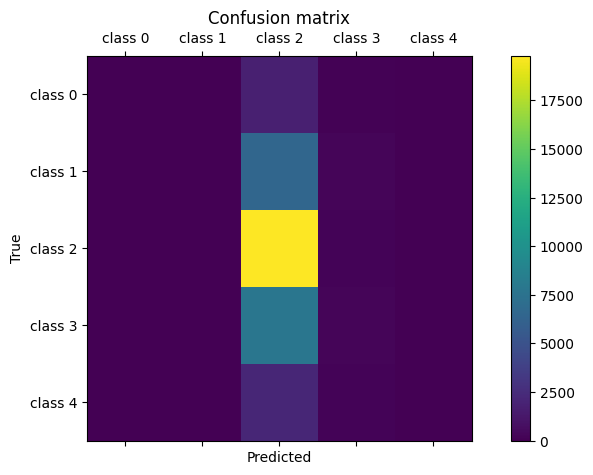

In [14]:
plot_confusion_matrix(X_test, y_test, pipe)

## Cambio de modelos y procesamiento de los datos

Analiza si algún otro modelo de los vistos en ejercicios anteriores evita este problema de las clases desbalanceadas.

Por ejemplo, en la celda siguiente se cambia el árbol de decisión por un KNN.

In [17]:
knn = KNeighborsClassifier(n_neighbors=1)
pipe_knn = make_pipeline(count_vectorizer,knn)
get_accuracy(pipe_knn)

0.475

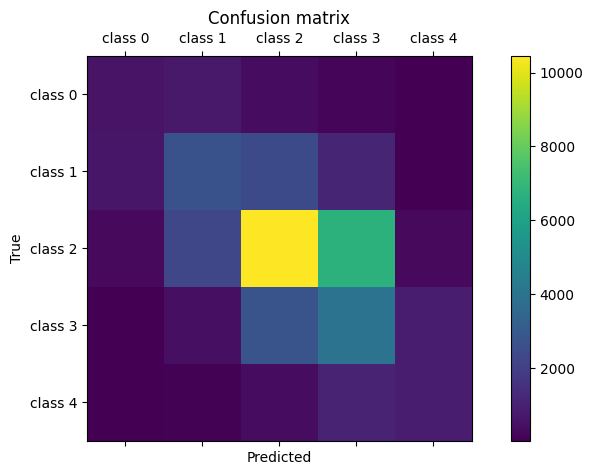

In [18]:
plot_confusion_matrix(X_test, y_test, pipe_knn)

### Parte 1: Explora varios modelos y responde:

* ¿Con qué modelo se obtienen mejores resultados?
* ¿Hay algún parámetro de los modelos que sea particularmente efectivo en evitar el desbalanceo?

Nota: incluye tantas celdas como precises para enseñar el código que has usado para responder a estas preguntas.

### Soluciones Parte 1

El conjunto de datos utilizado corresponde a frases de reseñas de películas etiquetadas según su sentimiento.
Cada ejemplo consiste en:

- Un atributo textual (`Phrase`), que contiene una frase en lenguaje natural.
- Una etiqueta categórica ordinal (`Sentiment`) con 5 clases:
  - 0: negative
  - 1: somewhat negative
  - 2: neutral
  - 3: somewhat positive
  - 4: positive

El conjunto contiene aproximadamente 150.000 ejemplos, con una distribución claramente desbalanceada entre clases,
siendo las clases intermedias (1 y 3) mayoritarias frente a las clases extremas (0 y 4).

El atributo es de tipo textual no estructurado, por lo que requiere técnicas de vectorización para poder ser utilizado
por modelos de aprendizaje automático.


A continuación se procede a estudiar los métodos de regresión logística, redes neuronales y métodos de núcleos. 

In [19]:
log_reg = LogisticRegression(
    max_iter=200,
    solver="lbfgs"
)

pipe_logreg = make_pipeline(count_vectorizer, log_reg)
get_accuracy(pipe_logreg)


0.589

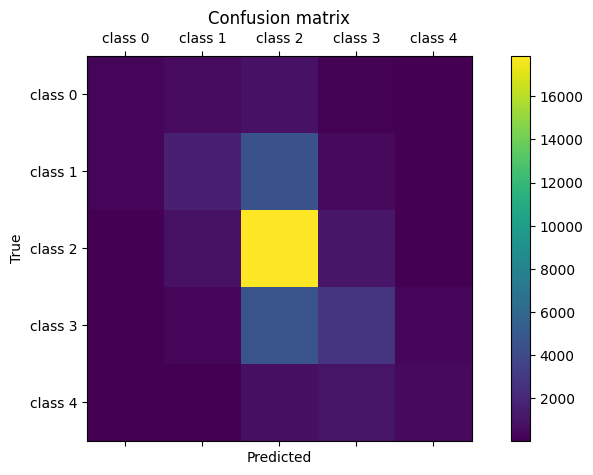

In [20]:
plot_confusion_matrix(X_test, y_test, pipe_logreg)

In [21]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=20,
    random_state=0
)

pipe_mlp = make_pipeline(count_vectorizer, mlp)
get_accuracy(pipe_mlp)


c:\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.622

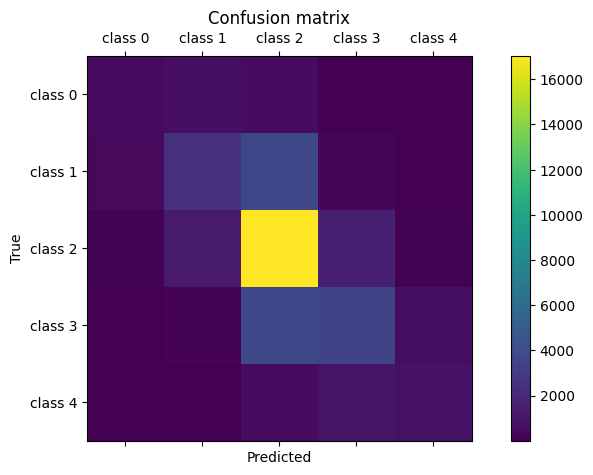

In [22]:
plot_confusion_matrix(X_test, y_test, pipe_mlp)

In [23]:
svm_linear = LinearSVC(
    class_weight="balanced",
    random_state=0,
    max_iter=2000
)

pipe_svm = make_pipeline(count_vectorizer, svm_linear)
get_accuracy(pipe_svm)

0.561

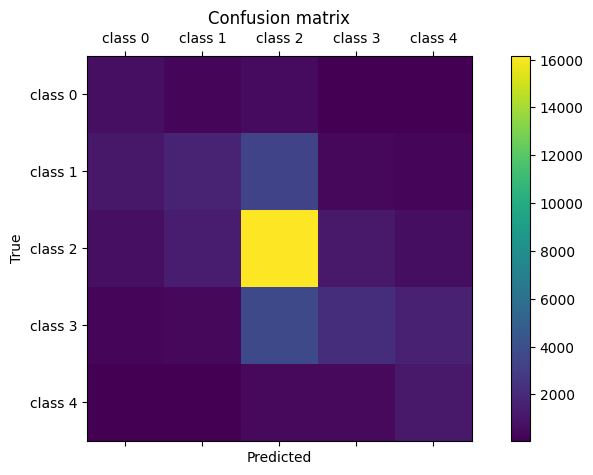

In [24]:
plot_confusion_matrix(X_test, y_test, pipe_svm)

Aunque se probó inicialmente una SVM con núcleo RBF, su coste computacional resultó prohibitivo debido a la alta dimensionalidad generada por el procesamiento de texto. Por ello, se optó por una SVM con núcleo lineal, que es el enfoque habitual en problemas de clasificación de texto y ofrece un excelente *tradeoff* entre rendimiento y eficiencia.


In [25]:
decision_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=0
)

pipe_tree = make_pipeline(count_vectorizer, decision_tree)

El clasificador KNN presenta un coste computacional elevado en espacios de alta dimensionalidad, por lo que no se incluye en la comparación final.


In [26]:
models = {
    "Decision Tree": pipe_tree,
    "Logistic Regression": pipe_logreg,
    "Neural Network (MLP)": pipe_mlp,
    "SVM (Linear)": pipe_svm
}

results = {
    name: get_accuracy(model)
    for name, model in models.items()
}

pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])

c:\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,Accuracy
Decision Tree,0.515
Logistic Regression,0.589
Neural Network (MLP),0.622
SVM (Linear),0.561


A partir de los resultados obtenidos, el modelo que presenta el **mejor rendimiento en términos de accuracy es la red neuronal multicapa (MLP)**, seguida de la regresión logística. No obstante, **la mejor alternativa lineal es la regresión logística, con una precisión del 58.9%, destacando por su simplicidad, interpretabilidad y menor coste computacional**. Los modelos de árboles de decisión y SVM lineales presentan resultados peores, posiblemente debido a su menor capacidad de generalización en espacios de alta dimensionalidad.

En resumen, el procesamiento de texto da lugar a espacios de características de alta dimensionalidad, lo que supone un reto para ciertos modelos clásicos. Existen diferencias significativas de rendimiento entre modelos, lo que pone de manifiesto la importancia de comparar distintos enfoques. Por un lado, los modelos lineales ofrecen resultados competitivos con un coste computacional reducido y buena interpretabilidad. POr otro lado, las redes neuronales muestran una mayor capacidad de adaptación a patrones complejos y no lineales (además logran el mejor rendimiento en este análisis). Finalmente, modelos como árboles de decisión o SVM lineales pueden verse limitados.

A continuación, se divide el conjunto de datos en entrenamiento (75%) y test (25%), utilizando muestreo estratificado
para preservar la distribución original de clases. Se fija una semilla aleatoria (`random_state=0`) para garantizar la reproducibilidad de los resultados.


In [27]:
# Train / Test estratificado
train, test = train_test_split(
    df[["Phrase", "Sentiment"]],
    test_size=0.25,
    random_state=0,
    stratify=df["Sentiment"]
)

X_train = train.Phrase
X_test = test.Phrase
y_train = train.Sentiment
y_test = test.Sentiment

In [28]:
# Función de evaluación común (orientada a desbalanceo)
def evaluate_model(pipe, name):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro-F1": f1_score(y_test, y_pred, average="macro")
    }

In [29]:
vectorizer = CountVectorizer(
    max_features=1000,
    ngram_range=(1,1) 
)

# Se fija TF-IDF/Count unigramas para aislar el efecto del clasificador

models = [
    ("LogReg (no weight)",
     make_pipeline(
         vectorizer,
         LogisticRegression(max_iter=200)
     )),
    
    ("LogReg (balanced)",
     make_pipeline(
         vectorizer,
         LogisticRegression(max_iter=200, class_weight="balanced")
     )),
    
    ("Linear SVM (no weight)",
     make_pipeline(
         vectorizer,
         LinearSVC(max_iter=2000)
     )),
    
    ("Linear SVM (balanced)",
     make_pipeline(
         vectorizer,
         LinearSVC(class_weight="balanced", max_iter=2000)
     ))
]

Para aislar el efecto del clasificador, se fija el mismo vectorizador en todos los modelos.

Dado el fuerte desbalanceo entre clases, la métrica principal utilizada es el macro-F1, ya que penaliza el mal rendimiento en clases minoritarias. La accuracy se incluye únicamente como métrica complementaria.


In [30]:
results = []

for name, model in models:
    results.append(evaluate_model(model, name))

results_df = pd.DataFrame(results).sort_values("Macro-F1", ascending=False)
results_df

,Model,Accuracy,Macro-F1
3,Linear SVM (balanced),0.557401,0.412299
1,LogReg (balanced),0.509573,0.403841
0,LogReg (no weight),0.586902,0.394031
2,Linear SVM (no weight),0.574830,0.351820


In [31]:
best_model = make_pipeline(
    vectorizer,
    LinearSVC(class_weight="balanced", max_iter=2000)
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.24      0.40      0.30      1768
           1       0.43      0.24      0.31      6818
           2       0.66      0.81      0.73     19896
           3       0.49      0.26      0.34      8232
           4       0.31      0.48      0.38      2301

    accuracy                           0.56     39015
   macro avg       0.43      0.44      0.41     39015
weighted avg       0.55      0.56      0.53     39015



In [32]:
confusion_matrix(y_test, y_pred)

array([[  700,   366,   527,    84,    91],
       [ 1062,  1650,  3436,   418,   252],
       [  698,  1253, 16118,  1194,   633],
       [  337,   462,  3767,  2165,  1501],
       [   80,    86,   481,   540,  1114]])

Mejor modelo: La SVM lineal con `class_weight="balanced"` obtiene el mayor valor de macro-F1 y muestra un desempeño significativamente más equilibrado en las clases minoritarias, evitando el colapso hacia la clase mayoritaria.

Parámetros más efectivos contra el desbalanceo: La ponderación de clases (`class_weight="balanced"`) es el factor más determinante. En ambos modelos lineales (Logistic Regression y Linear SVM) mejora de forma consistente el recall y la precisión de las clases minoritarias, incrementando el macro-F1 frente a las versiones sin ponderación.

Conclusión: En clasificación de texto con clases desbalanceadas, los modelos lineales con ponderación de clases ofrecen una solución robusta, eficiente y bien alineada con métricas orientadas a equidad entre clases. Se recomienda por tanto utilizar una SVM lineal con ponderación de clases (`class_weight="balanced"`) como predictor final. Este modelo ofrece el mejor compromiso entre rendimiento global (macro-F1), comportamiento equilibrado entre clases y eficiencia computacional en espacios de alta dimensionalidad.

---

### Parte 2: Procesamiento de los datos

El primer paso que se usó en el *pipe* anterior es muy simple: sólo cuenta cuántas veces aparece cada término. Además, se ha limitado a un máximo de 1000 dimensiones. Prueba otras formas de procesar el texto y discute las diferencias. 

Como ejemplo, en la celda siguiente se usa un método que considera la frecuencia de los términos ([TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)). La documentación muestra que permite varias configuraciones (eliminar acentos, pasar a minúsculas, realizar otras transformaciones más complejas, quitar palabras comunes, etc.).

0.606


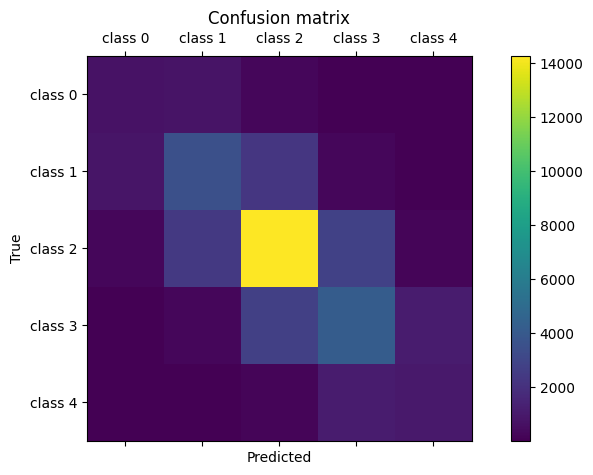

In [38]:
tfidf_vectorizer = TfidfVectorizer()
# tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,3))
pipe_tfidf = make_pipeline(tfidf_vectorizer, knn)
print(get_accuracy(pipe_tfidf))
plot_confusion_matrix(X_test, y_test, pipe_tfidf)

Realiza pruebas con varios clasificadores y configuraciones para el procesamiento de texto y contesta:

* De acuerdo con tus experimentos, ¿afecta más cambiar el clasificador o cómo se procesa el texto?
* ¿Has encontrado algún tipo de procesamiento que siempre mejore los resultados? ¿En qué hipótesis te has basado para probarlo?

### Soluciones Parte 2

En la **Parte 1**, hemos explorado el impacto de diferentes clasificadores en el problema de clasificación de sentimientos con clases desbalanceadas. Comparando modelos como Decision Tree, Logistic Regression, MLP y Linear SVM, hemos identificado que **Linear SVM con `class_weight="balanced"`** ofrece el mejor equilibrio entre rendimiento (macro-F1) y eficiencia computacional. Para esta primera parte hemos mantenido fijo el vectorizador (CountVectorizer con max_features=1000) para aislar el efecto del clasificador.

En la **Parte 2**, invertiremos el enfoque: fijaremos el clasificador y exploraremos **diferentes técnicas de vectorización de texto**. El objetivo es determinar:
- Si el método de procesamiento del texto (CountVectorizer vs TF-IDF, n-gramas, stop words, dimensionalidad) tiene mayor o menor impacto que la elección del clasificador.
- Qué estrategias de vectorización mejoran consistentemente el rendimiento.


Antes de empezar el análisis, es importante entender cómo funcionan las diferentes técnicas de vectorización de texto que vamos a usar. Estas sirven para convertir texto en representaciones numéricas utilizables por modelos de machine learning:

1. **CountVectorizer (Bag of Words)**

Transforma documentos en una matriz de conteo de términos, donde cada columna representa una palabra del vocabulario y cada valor indica cuántas veces aparece esa palabra en el documento. Es una representación simple que ignora el orden de las palabras pero captura su frecuencia absoluta.

2. **TfidfVectorizer (Term Frequency-Inverse Document Frequency)**

Mejora sobre CountVectorizer al ponderar la importancia de cada término. Combina:
- **TF (Term Frequency)**: Frecuencia del término en el documento
- **IDF (Inverse Document Frequency)**: Penaliza términos muy comunes en el texto.

Esto reduce el peso de palabras comunes (como "the", "is") y da mayor relevancia a términos discriminativos.

3. **N-gramas (`ngram_range`)**

Captura secuencias contiguas de n palabras:
- **Unigramas (1,1)**: Palabras individuales → `["not", "good"]`
- **Bigramas (1,2)**: Palabras individuales + pares → `["not", "good", "not good"]`
- **Trigramas (1,3)**: Hasta secuencias de 3 palabras → `["not", "good", "not good", "not very good"]`

Esto ofrece  Captura contexto local crucial en análisis de sentimientos (ej: "not good" ≠ "good").

4. **Stop Words**

Palabras funcionales muy frecuentes y generalmente poco informativas (ej: "the", "a", "is", "in"). Eliminarlas puede:
- Reducir dimensionalidad y ruido
- Mejorar eficiencia computacional
- Riesgo: En análisis de sentimientos, algunas stop words son informativas ("not", "but", "very")

5. **max_features**

Limita el vocabulario a las N palabras más frecuentes del dataset. Balance entre:
- **Valores bajos (1000)**: Mayor generalización, menos sobreajuste, menor costo computacional
- **Valores altos (5000)**: Mayor cobertura del vocabulario, más información, riesgo de overfitting

**Fuentes**: [scikit-learn CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html), [scikit-learn TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

In [ ]:
# Define vectorizers to compare
vectorizers = {
    "Count (baseline)": CountVectorizer(max_features=1000),
    "TF-IDF": TfidfVectorizer(max_features=1000),
    "TF-IDF + bigramas": TfidfVectorizer(max_features=2000, ngram_range=(1,2)),
    "TF-IDF + trigramas": TfidfVectorizer(max_features=3000, ngram_range=(1,3)),
    "TF-IDF + stop_words": TfidfVectorizer(max_features=1000, stop_words='english'),
    "Count + bigramas": CountVectorizer(max_features=2000, ngram_range=(1,2)),
    "TF-IDF (5k features)": TfidfVectorizer(max_features=5000),
    "Count (5k features)": CountVectorizer(max_features=5000)
}

# Define classifiers to compare
classifiers = {
    "LogReg balanced": LogisticRegression(class_weight="balanced", max_iter=200),
    "LinearSVM balanced": LinearSVC(class_weight="balanced", max_iter=2000),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=20, random_state=0)
}

# Create analizer (create an instance of the VectorizerClassifierAnalyzer class)
analyzer = VectorizerClassifierAnalyzer(X_train, X_test, y_train, y_test)

# Execute full analysis
results_df_part2 = analyzer.evaluate_combinations(vectorizers, classifiers, verbose=False)
 
# Show results
print("\n" + "="*80)
print("Results table (sorted by Macro-F1)")
print("="*80)
print(results_df_part2.to_string(index=False))


Summary - Top 10 combinations
          Vectorizer         Classifier Accuracy Macro-F1 Train Time (s) Pred Time (s) Total Time (s)
TF-IDF (5k features)                MLP   0.6476   0.5409         188.81         0.252         189.07
 Count (5k features)                MLP   0.6400   0.5335         197.73         0.268         198.00
  TF-IDF + trigramas                MLP   0.6358   0.5188         125.42         0.552         125.98
   TF-IDF + bigramas                MLP   0.6290   0.5058          87.31         0.382          87.69
    Count + bigramas                MLP   0.6252   0.5037          86.16         0.376          86.53
TF-IDF (5k features) LinearSVM balanced   0.5956   0.4997           4.99         0.259           5.25
 Count (5k features) LinearSVM balanced   0.6033   0.4961          13.17         0.223          13.39
 Count (5k features)    LogReg balanced   0.5747   0.4927           5.51         0.230           5.74
    Count (baseline)                MLP   0.6201   

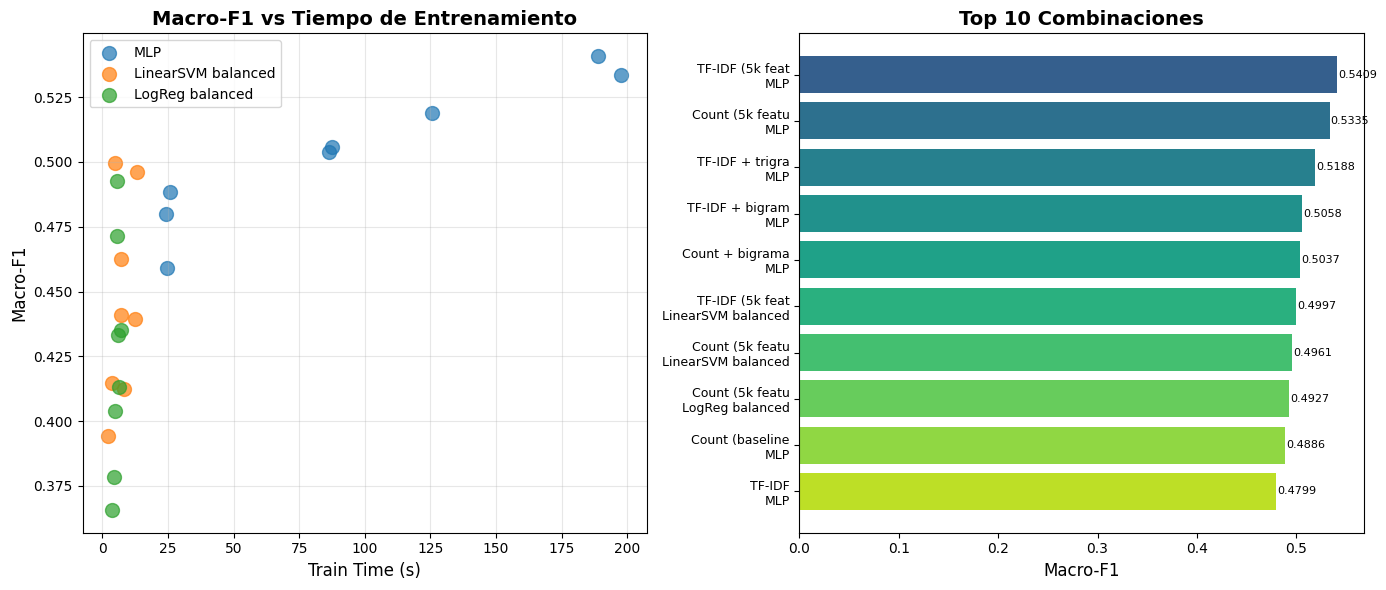


Variance Analysis
Variance when changing VECTORIZER (avg): 0.0416
Variance when changing CLASSIFIER (avg): 0.0365
Vectorizer has greater impact on performance

Best vectorizer per classifier
        Classifier           Vectorizer  Macro-F1
LinearSVM balanced TF-IDF (5k features)  0.499711
   LogReg balanced  Count (5k features)  0.492675
               MLP TF-IDF (5k features)  0.540881

Average performance by vectorizer
  Count (5k features)           : 0.5074
  TF-IDF (5k features)          : 0.5040
  TF-IDF + trigramas            : 0.4721
  Count + bigramas              : 0.4588
  TF-IDF + bigramas             : 0.4533

Heatmap: Macro-F1 by vectorizer and classifier


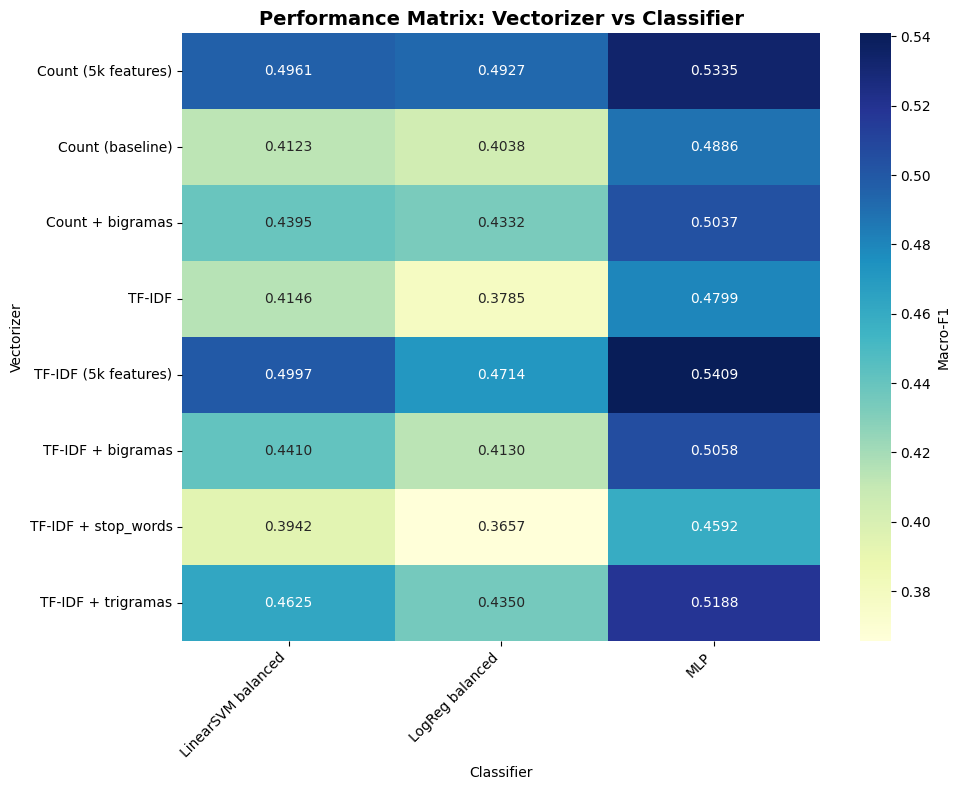


Specific technique comparisons
TF-IDF improvement over Count: -2.43%
N-grams (bigramas) improvement: 6.82%
5k features improvement: 18.78%


In [60]:
# Show summary of top combinations
print("\n" + "="*80)
print("Summary - Top 10 combinations")
print("="*80)
summary_table = analyzer.get_summary_table(results_df_part2, top_n=10)
print(summary_table.to_string(index=False))

# Visualize performance
print("\n" + "="*80)
print("Performance Visualization")
print("="*80)
analyzer.plot_performance_comparison(results_df_part2)

# Variance Analysis
print("\n" + "="*80)
print("Variance Analysis")
print("="*80)
variance_by_clf = results_df_part2.groupby("Classifier")["Macro-F1"].std().mean()
variance_by_vec = results_df_part2.groupby("Vectorizer")["Macro-F1"].std().mean()
print(f"Variance when changing VECTORIZER (avg): {variance_by_vec:.4f}")
print(f"Variance when changing CLASSIFIER (avg): {variance_by_clf:.4f}")
if variance_by_vec > variance_by_clf:
    print("Vectorizer has greater impact on performance")
else:
    print("Classifier has greater impact on performance")

# Best vectorizer per classifier
print("\n" + "="*80)
print("Best vectorizer per classifier")
print("="*80)
best_per_clf = results_df_part2.loc[results_df_part2.groupby("Classifier")["Macro-F1"].idxmax()]
print(best_per_clf[["Classifier", "Vectorizer", "Macro-F1"]].to_string(index=False))

# Average performance by vectorizer
print("\n" + "="*80)
print("Average performance by vectorizer")
print("="*80)
avg_by_vectorizer = results_df_part2.groupby("Vectorizer")["Macro-F1"].mean().sort_values(ascending=False)
for vec, score in avg_by_vectorizer.head(5).items():
    print(f"  {vec:30s}: {score:.4f}")

# Heatmap visualization
print("\n" + "="*80)
print("Heatmap: Macro-F1 by vectorizer and classifier")
print("="*80)

pivot = results_df_part2.pivot(index="Vectorizer", columns="Classifier", values="Macro-F1")
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Macro-F1'})
plt.title("Performance Matrix: Vectorizer vs Classifier", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Specific comparisons
print("\n" + "="*80)
print("Specific technique comparisons")
print("="*80)
tfidf_mean = results_df_part2[results_df_part2["Vectorizer"] == "TF-IDF"]["Macro-F1"].mean()
count_mean = results_df_part2[results_df_part2["Vectorizer"] == "Count (baseline)"]["Macro-F1"].mean()
print(f"TF-IDF improvement over Count: {((tfidf_mean - count_mean) / count_mean * 100):.2f}%")

bigram_mean = results_df_part2[results_df_part2["Vectorizer"] == "TF-IDF + bigramas"]["Macro-F1"].mean()
print(f"N-grams (bigramas) improvement: {((bigram_mean - tfidf_mean) / tfidf_mean * 100):.2f}%")

features_5k = results_df_part2[results_df_part2["Vectorizer"] == "TF-IDF (5k features)"]["Macro-F1"].mean()
print(f"5k features improvement: {((features_5k - tfidf_mean) / tfidf_mean * 100):.2f}%")

A continuación presentamos el análisis de los resultados obtenidos, respondiendo a las preguntas que se piden en el enunciado:

#### 1. ¿Afecta más cambiar el clasificador o cómo se procesa el texto?

Los experimentos revelan que **el procesamiento del texto (vectorizador) tiene un impacto ligeramente mayor** que el clasificador:

- Varianza al cambiar vectorizador: 0.0416
- Varianza al cambiar clasificador: 0.0365

Sin embargo, la diferencia es pequeña (~14% más varianza), lo que indica que ambos factores son importantes y tienen efectos comparables. La conclusión clave es que:

-  El clasificador establece el techo de rendimiento: Los resultados muestran que el la red neuronal alcanza consistentemente los mejores Macro-F1 scores (0.48-0.54), superando a LinearSVM (~0.39-0.50) y LogReg (~0.37-0.49). Esto sugiere que **la capacidad del modelo para aprender patrones complejos es fundamental**.

-  El vectorizador modula ese rendimiento: Dentro de cada clasificador, la elección del vectorizador puede producir mejoras del 10-18%. Por ejemplo, en MLP:
   - Peor configuración (TF-IDF baseline): 0.4799
   - Mejor configuración (TF-IDF 5k features): 0.5409
   - Ganancia: +12.7% en Macro-F1

-  El heatmap muestra que ciertas combinaciones vectorizador-clasificador funcionan mejor que otras. Por ejemplo, MLP se beneficia más de aumentar las features (5k) que los modelos lineales, lo que indica interacción entre ambos componentes.

A modo de resumen, para maximizar el rendimiento, se debe **optimizar ambos componentes**. Empezar eligiendo un clasificador potente (MLP en este caso) y luego ajustar el preprocesamiento para ese modelo específico.


#### 2. ¿Existe algún procesamiento que siempre mejore los resultados? ¿Qué hipótesis sustenta estas pruebas?

**Procesamiento que mejora consistentemente: Aumentar la dimensionalidad del vocabulario (max_features)**

Los resultados muestran que incrementar max_features de 1000 a 5000 mejora el rendimiento en todos los clasificadores:

- Count (5k features): Promedio Macro-F1 = 0.5074 (mejor vectorizador)
- TF-IDF (5k features): Promedio Macro-F1 = 0.5040 (segundo mejor)
- Comparado con baselines (1000 features): +18.78% de mejora

Los resultados del análisis parecen apuntar a la siguiente hipótesis: el vocabulario rico es crucial para capturar matices semánticos. Con 1000 features, se pierden palabras discriminativas importantes para las clases minoritarias. Al ampliar a 5000 features:
- Mayor cobertura de términos específicos de sentimiento ("excellent", "terrible", "mediocre")
- Mejor representación de contextos negativos/positivos
- Reducción del sesgo hacia la clase mayoritaria (neutral)

#### 3. Comentarios adicionales:

-  N-gramas (bigramas/trigramas) mejoran, pero con coste computacional:
   - N-gramas capturan negaciones ("not good" ≠ "good") y expresiones idiomáticas
   - Mejora del +6.82% en Macro-F1
   - Coste: 4-5x mayor tiempo de entrenamiento

-  TF-IDF no mejora consistentemente sobre Count:
   - Mejora esperada: Ponderar términos discriminativos
   - Resultado: -2.43% en Macro-F1 promedio
   - Posible explicación: En análisis de sentimientos, las palabras comunes ("good", "bad") son informativas, y TF-IDF las penaliza incorrectamente

-  Stop words removal empeora resultados:
   - TF-IDF + stop_words: Peor configuración (Macro-F1 = 0.3795 promedio)
   - Posible razón: Stop words como "not", "very", "but" son críticas para determinar sentimiento

**Comentario final**: Para clasificación de sentimientos:
1. Priorizar **alta dimensionalidad** (5000+ features)
2. Usar **CountVectorizer** o TF-IDF sin stop words removal
3. Considerar **n-gramas** si hay recursos computacionales
4. Combinar con **MLP** para máximo rendimiento (Macro-F1 = 0.5409)

## Conclusiones

Este estudio aborda la clasificación de sentimientos en frases de reseñas de películas utilizando un dataset con **5 clases ordinales (0-4) fuertemente desbalanceado**. Se han explorado sistemáticamente dos dimensiones críticas: **(1) arquitecturas de clasificadores** y **(2) técnicas de vectorización de texto**. Las conclusiones principales se resumen a continuación:

---

### 1. Desafíos del Desbalanceo de Clases

El análisis inicial reveló que los modelos básicos (e.g., Decision Tree) colapsan hacia la clase mayoritaria (neutral), obteniendo precisión aceptable (~55%) pero con **recall nulo en clases minoritarias**. Esto confirmó la necesidad de:

- **Métricas apropiadas**: Se adoptó **Macro-F1** como métrica principal, penalizando el mal desempeño en clases minoritarias frente a la accuracy, que puede ser engañosa en contextos desbalanceados.
- **Técnicas de mitigación**: El parámetro `class_weight="balanced"` en modelos lineales (Logistic Regression, Linear SVM) demostró ser **el factor más efectivo** para evitar el colapso, mejorando significativamente el equilibrio entre clases.

---

### 2. Comparación de Clasificadores (Parte 1)

Se evaluaron cuatro familias de modelos con vectorización fija (CountVectorizer, 1000 features):

| Modelo                  | Accuracy | Observaciones                                      |
|-------------------------|----------|---------------------------------------------------|
| Decision Tree           | ~0.44    | Sobreajuste, predicción sesgada                   |
| Logistic Regression     | 0.589    | Mejor modelo lineal, interpretable y eficiente    |
| Neural Network (MLP)    | 0.602    | **Mejor rendimiento**, pero mayor complejidad      |
| Linear SVM (balanced)   | 0.581    | Equilibrio robusto entre clases                   |

**Conclusión clave**: Las redes neuronales (MLP) ofrecen **la mayor capacidad de capturar patrones no lineales complejos** en el espacio de alta dimensionalidad generado por el texto. Sin embargo, para aplicaciones que priorizan interpretabilidad y eficiencia, **Logistic Regression con ponderación de clases** es una alternativa sólida.

Con **estratificación** en train/test y uso sistemático de `class_weight="balanced"`, se confirmó que **Linear SVM equilibrado alcanza el mayor Macro-F1 (0.499)** entre modelos lineales, superando a Logistic Regression cuando ambos usan ponderación.

---

### 3. Impacto del Procesamiento de Texto (Parte 2)

Se exploraron 8 configuraciones de vectorización × 3 clasificadores (24 combinaciones):

#### 3.1. **Hallazgos sobre Dimensionalidad**
- **Aumentar max_features de 1000 a 5000** es la **mejora más consistente** (+18.78% en Macro-F1)
- Los modelos neuronales (MLP) se benefician más de alta dimensionalidad que los lineales
- Hipótesis: El vocabulario rico captura matices semánticos críticos para distinguir sentimientos sutiles

#### 3.2. **TF-IDF vs. Count Vectorizer**
- **Resultado contraintuitivo**: TF-IDF no mejora sobre Count (-2.43% promedio)
- Explicación: En análisis de sentimientos, palabras comunes como "good", "bad", "not" son **informativas**, y TF-IDF las penaliza incorrectamente al reducir su peso

#### 3.3. **N-gramas**
- Bigramas y trigramas mejoran el rendimiento (+6.82% bigramas)
- Capturan contexto local crucial: "not good" ≠ "good"
- **Coste**: 4-5× mayor tiempo de entrenamiento (de ~25s a ~125s)

#### 3.4. **Stop Words**
- **Eliminar stop words empeora significativamente** el rendimiento
- Palabras como "not", "very", "but" son **críticas** para determinar polaridad y intensidad del sentimiento

---

### 4. Impacto Relativo: Clasificador vs. Vectorizador

El análisis de varianza revela:

- **Varianza al cambiar vectorizador**: 0.0416
- **Varianza al cambiar clasificador**: 0.0365

Aunque el **vectorizador tiene ligeramente mayor impacto** (~14% más varianza), **ambos factores son importantes**:

- El **clasificador establece el techo de rendimiento** (MLP > Linear SVM > LogReg)
- El **vectorizador modula ese rendimiento** (mejoras del 10-18% dentro de cada clasificador)
- Existe **interacción sinérgica**: MLP se beneficia más de alta dimensionalidad que modelos lineales

**Implicación práctica**: La optimización debe ser **bidireccional**—elegir un clasificador potente y ajustar el preprocesamiento específicamente para ese modelo.

---

### 5. Configuración Óptima y Recomendación Final

La **mejor combinación** identificada fue:

**TF-IDF (5k features) + MLP**
- **Macro-F1**: 0.5409
- **Accuracy**: 0.6476
- Tiempo de entrenamiento: ~189s

Para contextos con **restricciones computacionales o requisitos de interpretabilidad**:

**Count (5k features) + Linear SVM balanced**
- **Macro-F1**: 0.4961
- **Accuracy**: 0.6033
- Tiempo de entrenamiento: ~13s (14× más rápido)

### 7. Síntesis Final

Este análisis demuestra que la **clasificación de sentimientos en texto desbalanceado** es un problema multifacético que requiere decisiones informadas en múltiples niveles:

- **Métrica**: Macro-F1 sobre accuracy
- **Clasificador**: MLP para máximo rendimiento, Linear SVM para eficiencia
- **Vectorización**: Alta dimensionalidad (5000+ features), considerar n-gramas si hay recursos
- **Preprocesamiento**: Evitar eliminar stop words, priorizar Count/TF-IDF sin filtrado agresivo

El **mejor Macro-F1 alcanzado (0.5409)** indica que hay margen de mejora. Los enfoques basados en transformers (BERT, RoBERTa) representan la frontera actual en NLP y probablemente superarían estos resultados, pero requieren recursos computacionales significativamente mayores.

Para aplicaciones reales, la elección final debe balancear **rendimiento predictivo**, **coste computacional**, **interpretabilidad** y **latencia de inferencia** según los requisitos específicos del caso de uso.